# Final Model Comparison

Ky notebook mbledh rezultatet e modeleve te klasifikimit dhe i krahason me metrika te njejta: accuracy, precision macro, recall macro dhe F1 macro. Rezultatet lexohen nga folderi `data/processed/model_results`.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Ngarkimi i rezultateve te modeleve

Lexojme CSV-te e rezultateve per te gjitha modelet e klasifikimit qe jane punuar ne projekt. 

In [10]:
from pathlib import Path
import pandas as pd

# Gjejme folderin kryesor te projektit, pavaresisht nga ku hapet notebook-u.
project_root = Path.cwd()
while not (project_root / "data" / "processed" / "model_results").exists() and project_root != project_root.parent:
    project_root = project_root.parent

results_dir = project_root / "data" / "processed" / "model_results"
print("Model results directory:", results_dir)

model_result_files = {
    "Logistic Regression": "logistic_regression_results.csv",
    "Random Forest": "random_forest_results.csv",
    "KNN": "knn_results.csv",
    "Neural Network": "neural_network_results.csv",
}

metric_column_map = {
    "model": "Model",
    "accuracy": "Accuracy",
    "test_accuracy": "Accuracy",
    "precision_macro": "Precision Macro",
    "test_precision_macro": "Precision Macro",
    "precision macro": "Precision Macro",
    "recall_macro": "Recall Macro",
    "test_recall_macro": "Recall Macro",
    "recall macro": "Recall Macro",
    "f1_macro": "F1 Macro",
    "test_f1_macro": "F1 Macro",
    "f1 macro": "F1 Macro",
}

def load_model_metrics(model_name, file_name):
    path = results_dir / file_name
    if not path.exists():
        return None, {"Model": model_name, "File": file_name, "Status": "missing"}

    df = pd.read_csv(path)
    normalized_columns = {
        col: metric_column_map.get(col.strip().lower(), col)
        for col in df.columns
    }
    df = df.rename(columns=normalized_columns)

    row = df.iloc[0].copy()
    row["Model"] = model_name
    row["Source File"] = file_name

    status = {
        "Model": model_name,
        "File": file_name,
        "Status": "loaded",
    }
    return row, status

loaded_rows = []
load_status = []

for model_name, file_name in model_result_files.items():
    row, status = load_model_metrics(model_name, file_name)
    load_status.append(status)
    if row is not None:
        loaded_rows.append(row)

model_result_status = pd.DataFrame(load_status)
display(model_result_status)

Model results directory: c:\Users\PC\House-Price-Prediction-Machine-Learning-Models\data\processed\model_results


,Model,File,Status
0,Logistic Regression,logistic_regression_results.csv,loaded
1,Random Forest,random_forest_results.csv,loaded
2,KNN,knn_results.csv,loaded
3,Neural Network,neural_network_results.csv,loaded


In [11]:
comparison_columns = [
    "Model",
    "Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro",
    "Source File",
]

if loaded_rows:
    comparison_df = pd.DataFrame(loaded_rows)
    comparison_df = comparison_df.reindex(columns=comparison_columns)

    metric_columns = ["Accuracy", "Precision Macro", "Recall Macro", "F1 Macro"]
    for col in metric_columns:
        comparison_df[col] = pd.to_numeric(comparison_df[col], errors="coerce")

    comparison_df = comparison_df.sort_values("F1 Macro", ascending=False).reset_index(drop=True)
else:
    comparison_df = pd.DataFrame(columns=comparison_columns)

display(comparison_df)

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Source File
0,Random Forest,0.845992,0.847745,0.845870,0.846482,random_forest_results.csv
1,Neural Network,0.842019,0.845107,0.841780,0.842925,neural_network_results.csv
2,KNN,0.814209,0.816584,0.813802,0.814887,knn_results.csv
3,Logistic Regression,0.801122,0.805405,0.800841,0.802431,logistic_regression_results.csv


## 2. Tabela krahasuese kryesore

Te gjitha modelet krahasohen me te njejtat metrika ne test set. Tabela renditet sipas `F1 Macro` ne rend zbrites. Kjo perdoret si metrika kryesore sepse llogarit F1-score vecmas per secilen nga tri klasat (`Low`, `Medium`, `High`) dhe u jep atyre peshe te barabarte, pavaresisht madhesise se klases.

In [13]:
main_metric_columns = [
    "Model",
    "Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro",
]

main_comparison_table = (
    comparison_df[main_metric_columns]
    .dropna(subset=["F1 Macro"])
    .sort_values("F1 Macro", ascending=False)
    .reset_index(drop=True)
)

main_comparison_table.index = main_comparison_table.index + 1
main_comparison_table.index.name = "Rank"

display(
    main_comparison_table.style
    .format({column: "{:.4f}" for column in main_metric_columns[1:]})
    .highlight_max(subset=main_metric_columns[1:], color="#c6efce")
)

if not main_comparison_table.empty:
    best_model = main_comparison_table.iloc[0]
    print(
        f"Modeli me i mire sipas F1 Macro: {best_model['Model']} "
        f"(F1 Macro = {best_model['F1 Macro']:.4f})"
    )

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro
Rank,,,,,
1,Random Forest,0.8460,0.8477,0.8459,0.8465
2,Neural Network,0.8420,0.8451,0.8418,0.8429
3,KNN,0.8142,0.8166,0.8138,0.8149
4,Logistic Regression,0.8011,0.8054,0.8008,0.8024


Modeli me i mire sipas F1 Macro: Random Forest (F1 Macro = 0.8465)


## Interpretim
Random Forest arriti performancën më të mirë, me Accuracy = 0.8460 dhe F1 Macro = 0.8465. Vlerat e përafërta të precision dhe recall tregojnë performancë të balancuar ndërmjet tri klasave.

Neural Network u rendit i dyti me F1 Macro = 0.8429, vetëm 0.0036 më pak se Random Forest. Pra, të dy modelet janë shumë konkurruese, por Random Forest ka rezultate pak më të larta në të gjitha metrikat.

KNN arriti F1 Macro = 0.8149, ndërsa Logistic Regression rezultoi e fundit me F1 Macro = 0.8024. KNN e tejkaloi Logistic Regression me rreth 0.0125, kurse diferenca ndërmjet Random Forest dhe Logistic Regression është rreth 0.0441.

Në përgjithësi, metrikat brenda secilit model janë të balancuara. Megjithatë, confusion matrices dhe rezultatet për secilën klasë duhet të analizohen për të kuptuar konkretisht se cilat klasa ngatërrohen më shpesh.

## 3. Vizualizimi i metrikave

Grafiku krahason `Accuracy`, `Precision Macro`, `Recall Macro` dhe `F1 Macro` per te gjitha modelet. Te dhenat transformohen ne *long format* qe secila metrike te paraqitet me nje ngjyre te vecante.

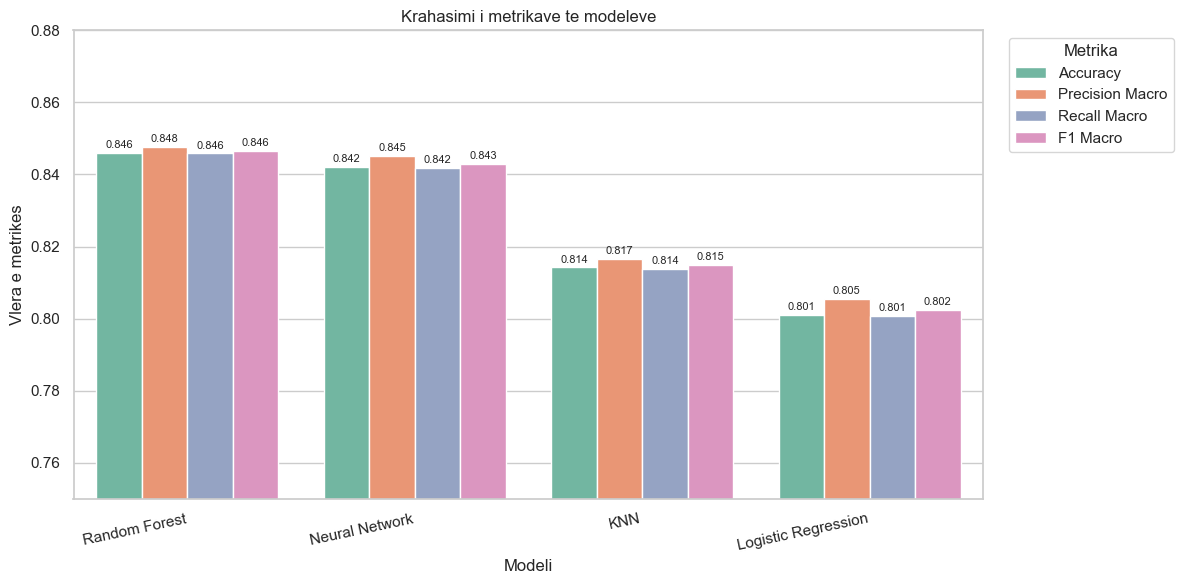

In [14]:
metrics_long = (
    main_comparison_table.reset_index()
    .melt(
        id_vars=["Rank", "Model"],
        value_vars=["Accuracy", "Precision Macro", "Recall Macro", "F1 Macro"],
        var_name="Metric",
        value_name="Score",
    )
)

model_order = main_comparison_table["Model"].tolist()

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=metrics_long,
    x="Model",
    y="Score",
    hue="Metric",
    order=model_order,
    palette="Set2",
)

ax.set_title("Krahasimi i metrikave te modeleve")
ax.set_xlabel("Modeli")
ax.set_ylabel("Vlera e metrikes")
ax.set_ylim(0.75, 0.88)
ax.legend(title="Metrika", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=12, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

### Interpretim i grafikut

Grafiku tregon se Random Forest ka performancën më të lartë në të katër metrikat, me vlera rreth 0.846–0.848. Neural Network renditet shumë afër, me vlera rreth 0.842–0.845, duke qenë alternativa më konkurruese.

KNN renditet i treti, me F1 Macro = 0.815, ndërsa Logistic Regression ka performancën më të ulët, me F1 Macro = 0.802. Megjithatë, brenda secilit model, katër metrikat janë shumë të përafërta. Kjo tregon se modelet kanë një balancë të mirë ndërmjet precision dhe recall dhe nuk mbështeten vetëm në performancën ndaj një klase.

Përzgjedhja finale bazohet kryesisht në F1 Macro, sepse kjo metrikë balancon precision dhe recall duke u dhënë peshë të barabartë klasave Low, Medium dhe High. Sipas kësaj metrike, Random Forest është modeli më i mirë, megjithëse diferenca prej rreth 0.0036 ndaj Neural Network është e vogël.

## 4. Confusion matrices per secilin model

Confusion matrices tregojne jo vetem sa parashikime jane te sakta, por edhe cilat klasa ngaterrohen nga secili model. Rreshtat paraqesin klasat reale dhe kolonat klasat e parashikuara. Per krahasim konsistent, klasat vendosen ne rendin `Low`, `Medium`, `High`. Secila qelize paraqet numrin e rasteve dhe perqindjen brenda klases reale.

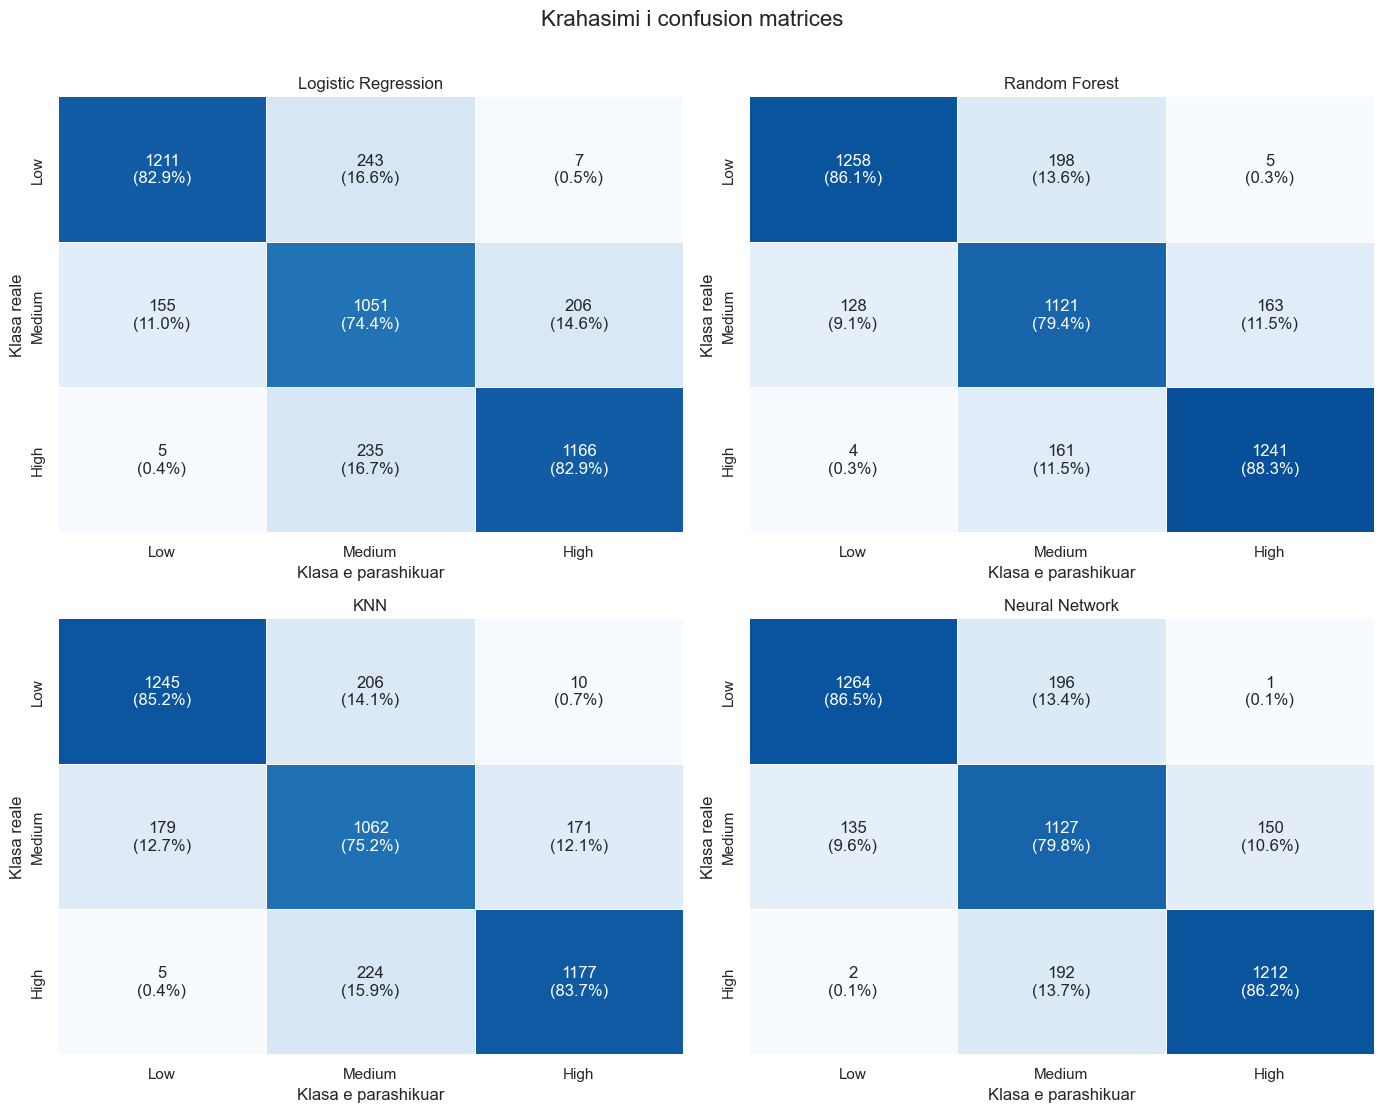

In [15]:
confusion_matrix_files = {
    "Logistic Regression": "logistic_regression_confusion_matrix.csv",
    "Random Forest": "random_forest_confusion_matrix.csv",
    "KNN": "knn_confusion_matrix.csv",
    "Neural Network": "neural_network_confusion_matrix.csv",
}

class_order = ["Low", "Medium", "High"]

def load_confusion_matrix(file_name):
    cm_path = results_dir / file_name
    if not cm_path.exists():
        return None

    cm_df = pd.read_csv(cm_path, index_col=0)
    cm_df.index = [str(label).replace("true_", "") for label in cm_df.index]
    cm_df.columns = [str(label).replace("pred_", "") for label in cm_df.columns]
    return cm_df.reindex(index=class_order, columns=class_order)

loaded_confusion_matrices = {
    model: load_confusion_matrix(file_name)
    for model, file_name in confusion_matrix_files.items()
}

available_matrices = {
    model: matrix
    for model, matrix in loaded_confusion_matrices.items()
    if matrix is not None
}

if not available_matrices:
    print("Nuk u gjet asnje confusion matrix.")
else:
    figure, axes = plt.subplots(2, 2, figsize=(14, 11))
    axes = axes.flatten()

    for axis, (model_name, cm_df) in zip(axes, available_matrices.items()):
        row_totals = cm_df.sum(axis=1).replace(0, 1)
        cm_percent = cm_df.div(row_totals, axis=0) * 100
        annotations = cm_df.astype(str) + "\n(" + cm_percent.map(lambda value: f"{value:.1f}%") + ")"

        sns.heatmap(
            cm_percent,
            annot=annotations,
            fmt="",
            cmap="Blues",
            vmin=0,
            vmax=100,
            cbar=False,
            linewidths=0.5,
            linecolor="white",
            ax=axis,
        )
        axis.set_title(model_name)
        axis.set_xlabel("Klasa e parashikuar")
        axis.set_ylabel("Klasa reale")

    for axis in axes[len(available_matrices):]:
        axis.set_visible(False)

    figure.suptitle("Krahasimi i confusion matrices", fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

In [16]:
confusion_summary_rows = []

for model_name, cm_df in available_matrices.items():
    for actual_class in class_order:
        errors = cm_df.loc[actual_class].drop(actual_class)
        most_confused_with = errors.idxmax()
        error_count = int(errors.max())
        class_total = int(cm_df.loc[actual_class].sum())
        confusion_summary_rows.append({
            "Model": model_name,
            "Actual Class": actual_class,
            "Most Confused With": most_confused_with,
            "Error Count": error_count,
            "Error Rate": error_count / class_total,
        })

confusion_error_summary = pd.DataFrame(confusion_summary_rows)
display(
    confusion_error_summary.style.format({"Error Rate": "{:.2%}"})
)

,Model,Actual Class,Most Confused With,Error Count,Error Rate
0,Logistic Regression,Low,Medium,243,16.63%
1,Logistic Regression,Medium,High,206,14.59%
2,Logistic Regression,High,Medium,235,16.71%
3,Random Forest,Low,Medium,198,13.55%
4,Random Forest,Medium,High,163,11.54%
5,Random Forest,High,Medium,161,11.45%
6,KNN,Low,Medium,206,14.10%
7,KNN,Medium,Low,179,12.68%
8,KNN,High,Medium,224,15.93%
9,Neural Network,Low,Medium,196,13.42%


### Interpretim i confusion matrices

Të gjitha modelet i dallojnë shumë mirë klasat ekstreme Low dhe High. Gabimet direkte ndërmjet tyre janë nën 1%, çka tregon se modelet rrallë i klasifikojnë shtëpitë me çmime të ulëta si të larta ose anasjelltas. Shumica e gabimeve ndodhin ndërmjet klasës Medium dhe klasave fqinje.

Random Forest ka numrin më të madh total të parashikimeve të sakta, me 3620 raste në diagonale. Ai klasifikon saktë 86.1% të rasteve Low, 79.4% të rasteve Medium dhe 88.3% të rasteve High. Gabimi i tij kryesor është klasifikimi i Low si Medium, me 198 raste ose 13.55%.

Neural Network është veçanërisht konkurrues për klasën Medium, ku arrin normën më të lartë të klasifikimit të saktë, 79.8%, krahasuar me 79.4% të Random Forest. Ai gjithashtu klasifikon saktë 86.5% të klasës Low, por është më i dobët se Random Forest për High, me 86.2% kundrejt 88.3%.
KNN klasifikon saktë 85.2% të rasteve Low, 75.2% të rasteve Medium dhe 83.7% të rasteve High. Gabimi i tij më i madh është klasifikimi i High si Medium, me 224 raste ose 15.93%.

Logistic Regression ka vështirësinë më të madhe me klasën Medium, ku klasifikon saktë vetëm 74.4% të rasteve. Gabimet më të larta janë High si Medium me 16.71% dhe Low si Medium me 16.63%.

Në përgjithësi, rezultatet konfirmojnë se Medium është klasa më e vështirë, për shkak të mbivendosjes së karakteristikave pranë kufijve të çmimeve. Random Forest ofron performancën më të mirë dhe më të balancuar, ndërsa Neural Network ka një avantazh të vogël vetëm në identifikimin e klasës Medium.

## 5. Classification reports

Classification reports mundesojne krahasimin e `precision`, `recall` dhe `F1-score` per secilen klase vecmas. Kjo analize eshte e rendesishme sepse nje rezultat i mire i pergjithshem nuk garanton performance te barabarte per klasat `Low`, `Medium` dhe `High`.

In [17]:
classification_report_files = {
    "Logistic Regression": "logistic_regression_classification_report.csv",
    "Random Forest": "random_forest_classification_report.csv",
    "KNN": "knn_classification_report.csv",
    "Neural Network": "neural_network_classification_report.csv",
}

def load_classification_report(file_name):
    report_path = results_dir / file_name
    if not report_path.exists():
        return None

    report_df = pd.read_csv(report_path, index_col=0)
    report_df.index.name = "Class"
    return report_df

classification_reports = {
    model: load_classification_report(file_name)
    for model, file_name in classification_report_files.items()
}
classification_reports = {
    model: report
    for model, report in classification_reports.items()
    if report is not None
}

for model_name, report_df in classification_reports.items():
    print(model_name)
    display(
        report_df.style.format({
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1-score": "{:.4f}",
            "support": "{:.0f}",
        })
    )

Logistic Regression


,precision,recall,f1-score,support
Class,,,,
Low,0.8833,0.8289,0.8552,1461
Medium,0.6874,0.7443,0.7147,1412
High,0.8455,0.8293,0.8373,1406
accuracy,0.8011,0.8011,0.8011,1
macro avg,0.8054,0.8008,0.8024,4279
weighted avg,0.8062,0.8011,0.8030,4279


Random Forest


,precision,recall,f1-score,support
Class,,,,
High,0.8808,0.8826,0.8817,1406
Low,0.9050,0.8611,0.8825,1461
Medium,0.7574,0.7939,0.7752,1412
accuracy,0.8460,0.8460,0.8460,1
macro avg,0.8477,0.8459,0.8465,4279
weighted avg,0.8484,0.8460,0.8468,4279


KNN


,precision,recall,f1-score,support
Class,,,,
Low,0.8712,0.8522,0.8616,1461
Medium,0.7118,0.7521,0.7314,1412
High,0.8667,0.8371,0.8517,1406
accuracy,0.8142,0.8142,0.8142,1
macro avg,0.8166,0.8138,0.8149,4279
weighted avg,0.8171,0.8142,0.8154,4279


Neural Network


,precision,recall,f1-score,support
Class,,,,
Low,0.9022,0.8652,0.8833,1461
Medium,0.7439,0.7982,0.7701,1412
High,0.8892,0.8620,0.8754,1406
accuracy,0.8420,0.8420,0.8420,1
macro avg,0.8451,0.8418,0.8429,4279
weighted avg,0.8457,0.8420,0.8433,4279


In [18]:
per_class_rows = []

for model_name, report_df in classification_reports.items():
    for class_name in class_order:
        if class_name not in report_df.index:
            continue
        per_class_rows.append({
            "Model": model_name,
            "Class": class_name,
            "Precision": report_df.loc[class_name, "precision"],
            "Recall": report_df.loc[class_name, "recall"],
            "F1-score": report_df.loc[class_name, "f1-score"],
            "Support": int(report_df.loc[class_name, "support"]),
        })

per_class_comparison = pd.DataFrame(per_class_rows)
per_class_comparison["Class"] = pd.Categorical(
    per_class_comparison["Class"], categories=class_order, ordered=True
)
per_class_comparison = per_class_comparison.sort_values(
    ["Class", "F1-score"], ascending=[True, False]
).reset_index(drop=True)

display(
    per_class_comparison.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
    })
)

,Model,Class,Precision,Recall,F1-score,Support
0,Neural Network,Low,0.9022,0.8652,0.8833,1461
1,Random Forest,Low,0.9050,0.8611,0.8825,1461
2,KNN,Low,0.8712,0.8522,0.8616,1461
3,Logistic Regression,Low,0.8833,0.8289,0.8552,1461
4,Random Forest,Medium,0.7574,0.7939,0.7752,1412
5,Neural Network,Medium,0.7439,0.7982,0.7701,1412
6,KNN,Medium,0.7118,0.7521,0.7314,1412
7,Logistic Regression,Medium,0.6874,0.7443,0.7147,1412
8,Random Forest,High,0.8808,0.8826,0.8817,1406
9,Neural Network,High,0.8892,0.8620,0.8754,1406


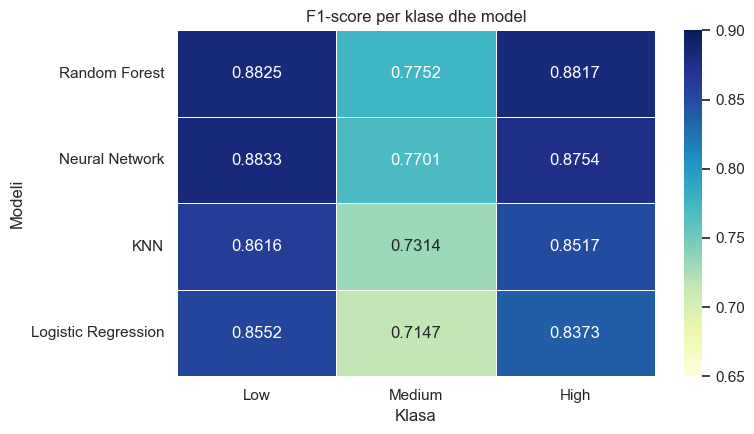

In [19]:
class_f1_pivot = per_class_comparison.pivot(
    index="Model", columns="Class", values="F1-score"
).reindex(columns=class_order)

class_f1_pivot = class_f1_pivot.reindex(
    main_comparison_table["Model"].tolist()
)

plt.figure(figsize=(8, 4.5))
sns.heatmap(
    class_f1_pivot,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    vmin=0.65,
    vmax=0.90,
    linewidths=0.5,
)
plt.title("F1-score per klase dhe model")
plt.xlabel("Klasa")
plt.ylabel("Modeli")
plt.tight_layout()
plt.show()

### Interpretim i performances per klase

Rezultatet tregojnë se klasa Medium është më e vështira për të gjitha modelet. F1-score për këtë klasë varion nga 0.7147 te Logistic Regression deri në 0.7752 te Random Forest, dukshëm më ulët se rezultatet për Low dhe High. Kjo përputhet me confusion matrices, ku shumica e gabimeve përfshijnë klasën Medium.

Për klasën Low, Neural Network ka F1-score më të lartë (0.8833), vetëm 0.0008 mbi Random Forest (0.8825). Random Forest ka precision më të lartë (0.9050), ndërsa Neural Network ka recall më të lartë (0.8652), prandaj Neural Network arrin një balancë pak më të mirë për këtë klasë.

Për Medium, Random Forest arrin F1-score më të lartë (0.7752). Neural Network ka recall pak më të mirë (0.7982 kundrejt 0.7939), por Random Forest ka precision më të lartë (0.7574 kundrejt 0.7439). Kjo do të thotë se Neural Network identifikon pak më shumë raste Medium, ndërsa Random Forest prodhon më pak parashikime të pasakta për këtë klasë.

Për klasën High, Random Forest është modeli më i mirë me F1-score 0.8817, i ndjekur nga Neural Network me 0.8754. Neural Network ka precision më të lartë (0.8892), por Random Forest ka recall më të lartë (0.8826), duke identifikuar më shumë raste reale High.

Në përgjithësi, Random Forest fiton në dy nga tri klasat dhe ka performancën më të balancuar. Neural Network është shumë konkurrues dhe fiton me diferencë minimale për Low. KNN renditet i treti për të gjitha klasat, ndërsa Logistic Regression ka rezultatet më të ulëta, veçanërisht për Medium. Kjo shpjegon pse Random Forest arrin edhe F1 Macro më të lartë.

## 6. Diskutim: cili model performoi më mirë?

Sipas rezultateve në test set, **Random Forest** është modeli me performancën më të mirë. Varianti `RF - Gini Regularized` arriti:

- `Accuracy = 0.8460`
- `Precision Macro = 0.8477`
- `Recall Macro = 0.8459`
- `F1 Macro = 0.8465`

Afërsia ndërmjet këtyre metrikave tregon performancë të balancuar për të tri klasat.

**Neural Network** u rendit i dyti me `Accuracy = 0.8420` dhe `F1 Macro = 0.8429`. Diferenca prej vetëm `0.0036` në F1 Macro tregon se ai është shumë konkurrues. **KNN** u rendit i treti me `F1 Macro = 0.8149`, ndërsa **Logistic Regression** arriti rezultatin më të ulët, me `F1 Macro = 0.8024`.

Analiza sipas klasave tregon se Random Forest arriti F1-score më të lartë për:

- `Medium`: `0.7752`
- `High`: `0.8817`

Neural Network ishte pak më i mirë për klasën `Low`, me F1-score `0.8833`, kundrejt `0.8825` të Random Forest. Megjithatë, Random Forest fitoi në dy nga tri klasat dhe ofroi performancën më të balancuar në përgjithësi.

Confusion matrices tregojnë se Random Forest realizoi numrin më të madh të parashikimeve të sakta, gjithsej `3620`. Ai klasifikoi saktë:

- `86.1%` të rasteve `Low`
- `79.4%` të rasteve `Medium`
- `88.3%` të rasteve `High`

Gabimet direkte ndërmjet `Low` dhe `High` ishin pothuajse zero. Vështirësia kryesore mbetet klasa `Medium`, e cila ka karakteristika të mbivendosura me klasat fqinje.

Performanca e Random Forest shpjegohet nga aftësia e tij për të kapur marrëdhënie jo-lineare dhe interaksione komplekse ndërmjet lokacionit, sipërfaqes së banimit, `grade`, largësisë nga qendra dhe veçorive të krijuara gjatë feature engineering. Ndryshe nga Logistic Regression, ai nuk supozon kufij linearë ndërmjet klasave.

Zgjedhja e variantit `RF - Gini Regularized` ishte e arsyeshme edhe për kontrollimin e overfitting-ut. Ky variant kishte diferencë më të vogël ndërmjet train dhe validation sesa modelet e pakufizuara. Pas trajnimit me train + validation, ai ruajti performancë të lartë në test set, duke treguar gjeneralizim të mirë.

**Përfundim:** Random Forest rekomandohet si modeli final, sepse ka F1 Macro dhe accuracy më të lartë, fiton në dy nga tri klasat dhe ka numrin më të madh të parashikimeve të sakta. Megjithatë, avantazhi ndaj Neural Network është i vogël, prandaj edhe Neural Network mbetet alternativë e fortë.

## 7. Trade-off mes modeleve

Zgjedhja e modelit nuk duhet të bazohet vetëm në rezultatin më të lartë të `F1 Macro`. Duhet të merren parasysh edhe interpretueshmëria, koha e trajnimit dhe predikimit, ndjeshmëria ndaj përgatitjes së të dhënave dhe kompleksiteti i mirëmbajtjes.

### Random Forest

Random Forest arriti performancën më të mirë:

- `Accuracy = 0.8460`
- `F1 Macro = 0.8465`
- F1-score për `Low = 0.8825`
- F1-score për `Medium = 0.7752`
- F1-score për `High = 0.8817`

Modeli mund të kapë marrëdhënie jo-lineare dhe interaksione komplekse ndërmjet veçorive. Varianti `RF - Gini Regularized` tregoi edhe gjeneralizim të mirë në test set.

Kufizimi kryesor është interpretueshmëria. Feature importance dhe paraqitja e një peme individuale ndihmojnë në analizë, por nuk shpjegojnë plotësisht vendimin e gjithë ensemble-it. Për më tepër, feature importance paraqet rëndësi relative dhe jo shkakësi.

### Logistic Regression

Logistic Regression është modeli më i thjeshtë dhe më transparent. Koeficientet tregojnë drejtimin dhe fuqinë relative të lidhjes së veçorive me secilën klasë.

Modeli arriti `F1 Macro = 0.8024`, rreth `0.0441` më pak se Random Forest. Rezultati më i dobët ishte për klasën `Medium`, me F1-score `0.7147`. Kjo tregon se kufijtë linearë nuk e përfaqësojnë plotësisht strukturën komplekse të këtij dataset-i.

Logistic Regression mbetet zgjedhje e përshtatshme kur transparenca dhe thjeshtësia janë më të rëndësishme se performanca maksimale.

### KNN

KNN arriti `F1 Macro = 0.8149`, duke performuar më mirë se Logistic Regression, por më dobët se Random Forest dhe Neural Network.

Performanca e tij varet shumë nga:

- Scaling i veçorive
- Metrika e distancës
- Numri i fqinjëve
- Mënyra e peshimit të fqinjëve

Trajnimi i KNN është i thjeshtë, por predikimi mund të jetë më i ngadalshëm, sepse për çdo rast të ri duhet të llogariten distancat ndaj mostrave të trajnimit. Modeli gjithashtu nuk ofron një shpjegim global të thjeshtë të vendimeve.

### Neural Network

Neural Network ishte modeli i dytë më i mirë, me:

- `Accuracy = 0.8420`
- `F1 Macro = 0.8429`

Diferenca ndaj Random Forest ishte vetëm `0.0036` në F1 Macro. Neural Network arriti rezultatin më të mirë për klasën `Low`, me F1-score `0.8833`, dhe recall më të lartë për `Medium`, me `0.7982`.

Megjithatë, ky model kërkon më shumë tuning të arkitekturës, learning rate, batch size, numrit të epoch-ave dhe regularizimit. Trajnimi është më i kushtueshëm dhe vendimet janë më pak transparente se te modelet e tjera.

### Përmbledhje e trade-off-it

- **Performanca më e mirë e përgjithshme:** Random Forest
- **Alternativa më konkurruese:** Neural Network
- **Interpretueshmëria më e lartë:** Logistic Regression
- **Trajnimi më i thjeshtë, por predikimi më i kushtueshëm:** KNN
- **Kompleksiteti dhe kostoja më e lartë e trajnimit:** Neural Network

Kur prioriteti është performanca prediktive dhe balanca ndërmjet klasave, Random Forest është zgjedhja më e mirë. Kur transparenca është kërkesa kryesore, Logistic Regression mund të preferohet, duke pranuar një ulje prej rreth `0.0441` në F1 Macro.

## 8. Përfundim final

`RF - Gini Regularized` rekomandohet si modeli final, sepse arriti performancën më të lartë në test set, me `Accuracy = 0.8460` dhe `F1 Macro = 0.8465`.

Confusion matrix tregon se modeli dallon mirë klasat `Low` dhe `High`, ndërsa vështirësia kryesore mbetet klasa `Medium`.

Neural Network ishte shumë afër, me vetëm `0.0036` më pak në F1 Macro. Megjithatë, Random Forest u zgjodh për performancën pak më të lartë dhe analizën më të lehtë përmes feature importance.

Ky rekomandim bazohet kryesisht në performancën prediktive. Nëse prioriteti kryesor do të ishte transparenca, Logistic Regression do të ishte alternativë më e përshtatshme, por me performancë më të ulët.